In [1]:
import pandas as pd
df = pd.read_csv('Datasets/salaries.csv')
df.head()

,company,job,degree,salary_more_then_100k
0,google,sales executive,bachelors,0
1,google,sales executive,masters,0
2,google,business manager,bachelors,1
3,google,business manager,masters,1
4,google,computer programmer,bachelors,0


In [2]:
df.isnull().sum()

company                  0
job                      0
degree                   0
salary_more_then_100k    0
dtype: int64

In [3]:
inputs = df.drop('salary_more_then_100k',axis=1)
target = df['salary_more_then_100k']

In [4]:
target

0     0
1     0
2     1
3     1
4     0
5     1
6     0
7     0
8     0
9     1
10    1
11    1
12    1
13    1
14    1
15    1
Name: salary_more_then_100k, dtype: int64

In [5]:
#encode categorical features
from sklearn.preprocessing import LabelEncoder

In [6]:
le_company = LabelEncoder()
le_job = LabelEncoder()
le_degree = LabelEncoder()

In [7]:
inputs['company_n']=le_company.fit_transform(inputs['company'])
inputs['job_n']=le_job.fit_transform(inputs['job'])
inputs['degree_n']=le_degree.fit_transform(inputs['degree'])
inputs.head()

,company,job,degree,company_n,job_n,degree_n
0,google,sales executive,bachelors,2,2,0
1,google,sales executive,masters,2,2,1
2,google,business manager,bachelors,2,0,0
3,google,business manager,masters,2,0,1
4,google,computer programmer,bachelors,2,1,0


In [8]:
inputs_n=inputs.drop(columns=['company','job','degree'])

In [9]:
inputs_n.head()

,company_n,job_n,degree_n
0,2,2,0
1,2,2,1
2,2,0,0
3,2,0,1
4,2,1,0


In [10]:
from sklearn import tree

In [11]:
model = tree.DecisionTreeClassifier()

In [12]:
model.fit(inputs_n,target)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [13]:
model.score(inputs_n,target)

1.0

In [14]:
Bool=model.predict([[2,0,1]])
if Bool==0:
    print('Salary not more than 100000')
else:
    print('yeahhh salary more than 100000')

yeahhh salary more than 100000


C:\Users\user\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## ASS 
### To build a decision tree algorithm for the titanic dataset

In [15]:
df_tit=pd.read_csv('Datasets/titanic.csv')
df_tit.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [16]:
df_tit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [19]:
from sklearn.feature_selection import SelectKBest, chi2
X=df_tit.drop(columns=['Survived','Name','Cabin'])
y=df_tit.Survived

In [21]:
from sklearn.preprocessing import LabelEncoder
le_sex=LabelEncoder()
X['Sex_n']=le_sex.fit_transform(X['Sex'])

In [62]:
le_Emb=LabelEncoder()
X['Embarked_n']=le_Emb.fit_transform(X['Embarked'])

In [22]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Sex          891 non-null    object 
 3   Age          714 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Ticket       891 non-null    object 
 7   Fare         891 non-null    float64
 8   Embarked     889 non-null    object 
 9   Sex_n        891 non-null    int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 69.7+ KB


In [51]:
mod_embarked=X['Embarked'].value_counts().idxmax()
X['Embarked']=X['Embarked'].fillna(mod_embarked)

In [38]:
mean_age=X.groupby('Sex').Age.mean()

In [34]:
X['Age']=X.apply(lambda x:mean_age[x['Sex']] if pd.isnull(x['Age'])
                else x['Age'], axis=1)

In [64]:
X=X.drop(columns=['Embarked'])

In [65]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Age          891 non-null    float64
 3   SibSp        891 non-null    int64  
 4   Parch        891 non-null    int64  
 5   Fare         891 non-null    float64
 6   Sex_n        891 non-null    int64  
 7   Embarked_n   891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB


In [66]:
chi2_selector = SelectKBest(score_func=chi2, k=5)
X_kbest = chi2_selector.fit_transform(X, y)

In [67]:
selected_features = X.columns[chi2_selector.get_support()]
selected_features

Index(['Pclass', 'Age', 'Fare', 'Sex_n', 'Embarked_n'], dtype='object')

In [108]:
X_input=X[selected_features]
X_input.head()

,Pclass,Age,Fare,Sex_n,Embarked_n
0,3,22.0,7.2500,1,2
1,1,38.0,71.2833,0,0
2,3,26.0,7.9250,0,2
3,1,35.0,53.1000,0,2
4,3,35.0,8.0500,1,2


In [130]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_input, y, test_size=0.2,random_state=4)

In [131]:
model2=tree.DecisionTreeClassifier()
model2.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [132]:
y_pred=model2.predict(X_test)

In [133]:
model2.score(X_test,y_test)

0.8212290502793296

NameError: name 'plt' is not defined

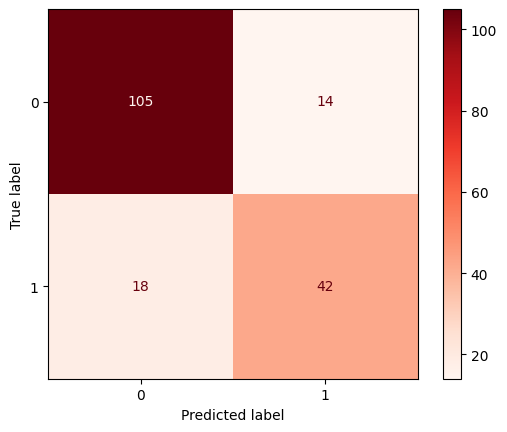

In [134]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Reds')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn import linear_model
model3=linear_model.LogisticRegression()
model3.fit()